# Analyse de clusters des cas COVID-19 positifs
## Objectif : Identifier des profils de patients positifs à la COVID-19 en fonction de leurs symptômes et comorbidités.

Ce notebook suit les étapes suivantes :
1. Restreindre la population aux cas positifs (sérologie positive).
2. Sélectionner les variables de symptômes et de comorbidités.
3. Préparer les données (binarisation, gestion des valeurs manquantes).
4. Choisir une méthode de clustering adaptée aux données binaires.
5. Déterminer le nombre optimal de clusters.
6. Décrire et interpréter les clusters.
7. Comparer les clusters et analyser leur association avec les variables démographiques.
8. Visualisations avec Plotly.

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Pour utiliser kmodes (clustering de données catégorielles) si besoin
# from kmodes.kmodes import KModes

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## 1. Chargement des données
Le fichier Excel `Base_population_Netoyé Pop_VF.xlsx` doit être présent dans le répertoire de travail.

In [2]:
# 1. Chargement des données
df = pd.read_excel("C:/Users/achao/Desktop/STAGE/Covid_Niger/Files of pj/base_covid_population_vrai/Base_population_Netoyée Pop_VF.xlsx")


print("Aperçu des données :")
display(df.head())
print(f"Dimensions du jeu de données : {df.shape}")

Aperçu des données :


,Code,Longitude,Latitude,Quartier_corrige,Population,Sexe,Age,Categorie_age,Profession,Statut_matrimonial,...,Frissons,Nausées,Dyspnée,Vomissements,Sueurs,Eruption cutanée,Odynophagie,Conjonctivite,Rhinorragie,Serologie
0,14-01,2.09289,13.48281,Banga bana,24700,Femme,19,Adolescent,Elève/Etudiant,Marié,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
1,15-02,2.09289,13.48281,Banga bana,24700,Femme,60,Personne âgée,Sans emploi,Veuf,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
2,15-03,2.09289,13.48281,Banga bana,24700,Homme,6,Enfant,Sans emploi,Célibataire,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
3,15-05,2.09289,13.48281,Banga bana,24700,Femme,16,Adolescent,Sans emploi,Marié,...,Non,Non,Non,Non,Non,Oui,Non,Non,Non,Positif
4,15-06,2.09289,13.48281,Banga bana,24700,Homme,2,Enfant,Sans emploi,Célibataire,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Négatif


Dimensions du jeu de données : (4318, 36)


In [3]:
# Informations générales sur les colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4318 entries, 0 to 4317
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Code                          4318 non-null   object 
 1   Longitude                     4318 non-null   float64
 2   Latitude                      4318 non-null   float64
 3   Quartier_corrige              4318 non-null   object 
 4   Population                    4318 non-null   int64  
 5   Sexe                          4318 non-null   object 
 6   Age                           4318 non-null   int64  
 7   Categorie_age                 4318 non-null   object 
 8   Profession                    4318 non-null   object 
 9   Statut_matrimonial            4318 non-null   object 
 10  Diabte                        4318 non-null   object 
 11  HTA                           4318 non-null   object 
 12  Maladie_cardiaque             4318 non-null   object 
 13  Por

## 2. Population d'étude : cas positifs uniquement
La variable `Serologie` indique le résultat : 'Positif' ou 'Négatif'.

In [4]:
# Filtrer les individus avec sérologie positive
df_positif = df[df['Serologie'] == 'Positif'].copy()

print(f"Nombre total d'individus dans l'étude : {len(df)}")
print(f"Nombre de cas positifs : {len(df_positif)}")
print(f"Pourcentage de positifs : {len(df_positif)/len(df)*100:.2f}%")

Nombre total d'individus dans l'étude : 4318
Nombre de cas positifs : 1470
Pourcentage de positifs : 34.04%


## 3. Sélection des variables pour le clustering
### A. Symptômes
Liste des colonnes correspondant aux symptômes :

In [5]:
# Colonnes de symptômes (d'après l'entête)
symptom_cols = [
    'Céphalée', 'Douleurs articulaires', 'Fièvre', 'Douleurs musculaires',
    'Douleurs abdominales', 'Toux', 'Rhinorrhée', 'Anosmie', 'Ageusie',
    'Frissons', 'Nausées', 'Dyspnée', 'Vomissements', 'Sueurs',
    'Eruption cutanée', 'Odynophagie', 'Conjonctivite', 'Rhinorragie'
]



### B. Comorbidités
Liste des colonnes pour les comorbidités :

In [6]:
comorbidity_cols = ['Diabte', 'HTA', 'Maladie_cardiaque']

## 4. Préparation des données : binarisation
Les variables sont de type 'Oui'/'Non'. On les convertit en 1/0.
On vérifie également qu'il n'y a pas d'autres valeurs (comme 'Rare' ou 'Fréquent') pour ces colonnes. Dans notre jeu, les symptômes sont uniquement Oui/Non, mais on vérifie par précaution.

In [7]:
def binarize(df, cols):
    """Convertit les colonnes en binaire (Oui=1, Non=0).
       Si d'autres valeurs apparaissent, on les considère comme manquantes ou on les ignore."""
    for col in cols:
        # Vérifier les valeurs uniques
        uniq = df[col].unique()
        print(f"{col} : valeurs uniques = {uniq}")
        # Mapping
        df[col] = df[col].map({'Oui': 1, 'Non': 0})
        # Si des valeurs non mappées (ex: NaN) apparaissent, on les laisse telles quelles (elles seront traitées plus tard)
    return df

print("--- Binarisation des symptômes ---")
df_positif = binarize(df_positif, symptom_cols)
print("\n--- Binarisation des comorbidités ---")
df_positif = binarize(df_positif, comorbidity_cols)

--- Binarisation des symptômes ---
Céphalée : valeurs uniques = ['Non' 'Oui']
Douleurs articulaires : valeurs uniques = ['Non' 'Oui']
Fièvre : valeurs uniques = ['Non' 'Oui']
Douleurs musculaires : valeurs uniques = ['Non' 'Oui']
Douleurs abdominales : valeurs uniques = ['Oui' 'Non']
Toux : valeurs uniques = ['Non' 'Oui']
Rhinorrhée : valeurs uniques = ['Non' 'Oui']
Anosmie : valeurs uniques = ['Non' 'Oui']
Ageusie : valeurs uniques = ['Non' 'Oui']
Frissons : valeurs uniques = ['Non' 'Oui']
Nausées : valeurs uniques = ['Non' 'Oui']
Dyspnée : valeurs uniques = ['Non' 'Oui']
Vomissements : valeurs uniques = ['Non' 'Oui']
Sueurs : valeurs uniques = ['Non' 'Oui']
Eruption cutanée : valeurs uniques = ['Non' 'Oui']
Odynophagie : valeurs uniques = ['Non' 'Oui']
Conjonctivite : valeurs uniques = ['Non' 'Oui']
Rhinorragie : valeurs uniques = ['Non' 'Oui']

--- Binarisation des comorbidités ---
Diabte : valeurs uniques = ['Non' 'Oui']
HTA : valeurs uniques = ['Non' 'Oui']
Maladie_cardiaque : val

## 6. Suppression des variables à très faible fréquence (optionnel)
On peut retirer les symptômes qui apparaissent chez moins de 5% des individus pour éviter le bruit. On calcule la prévalence de chaque symptôme.

In [8]:
threshold=0.01
prevalence_symp = df_positif[symptom_cols].mean().sort_values()
print("Prévalence des symptômes :")
print(prevalence_symp)

low_freq = prevalence_symp[prevalence_symp < threshold].index.tolist()
print(f"\nSymptômes avec prévalence < 5% : {low_freq}")

# Décision : on les retire pour le clustering (sinon ils n'apportent pas d'info)
symptom_cols_clean = [col for col in symptom_cols if col not in low_freq]
print(f"Nombre de symptômes conservés : {len(symptom_cols_clean)}")

Prévalence des symptômes :
Rhinorragie              0.002041
Anosmie                  0.002721
Ageusie                  0.004082
Dyspnée                  0.005442
Frissons                 0.006122
Eruption cutanée         0.018367
Odynophagie              0.020408
Vomissements             0.021088
Sueurs                   0.021088
Conjonctivite            0.021769
Nausées                  0.023129
Toux                     0.051020
Rhinorrhée               0.057823
Douleurs abdominales     0.093878
Fièvre                   0.100680
Douleurs musculaires     0.134694
Douleurs articulaires    0.145578
Céphalée                 0.187075
dtype: float64

Symptômes avec prévalence < 5% : ['Rhinorragie', 'Anosmie', 'Ageusie', 'Dyspnée', 'Frissons']
Nombre de symptômes conservés : 13


## 7. Matrices pour le clustering
On extrait les matrices binaires pour les symptômes et pour les comorbidités.

In [9]:
X_symptom = df_positif[symptom_cols_clean].values
X_comorbidity = df_positif[comorbidity_cols].values

print(f"Matrice symptômes : {X_symptom.shape}")
print(f"Matrice comorbidités : {X_comorbidity.shape}")

Matrice symptômes : (1470, 13)
Matrice comorbidités : (1470, 3)


## 8. Choix de la méthode de clustering
Les données sont binaires. Une distance appropriée est la distance de Jaccard (ou Dice). On peut utiliser le clustering hiérarchique avec cette distance, puis couper le dendrogramme pour obtenir des groupes. Cette méthode est intuitive et permet de visualiser la hiérarchie. On utilisera également le score de silhouette pour valider le nombre de clusters.

### Justification
- Les données binaires ne sont pas adaptées à la distance euclidienne.
- La distance de Jaccard mesure la dissimilarité entre deux ensembles binaires (intersection sur union).
- Le clustering hiérarchique ne nécessite pas de spécifier le nombre de clusters à l'avance et fournit un dendrogramme.
- On peut ensuite déterminer le nombre de clusters par la méthode du coude ou le score de silhouette.

### 8.1 Clustering des symptômes

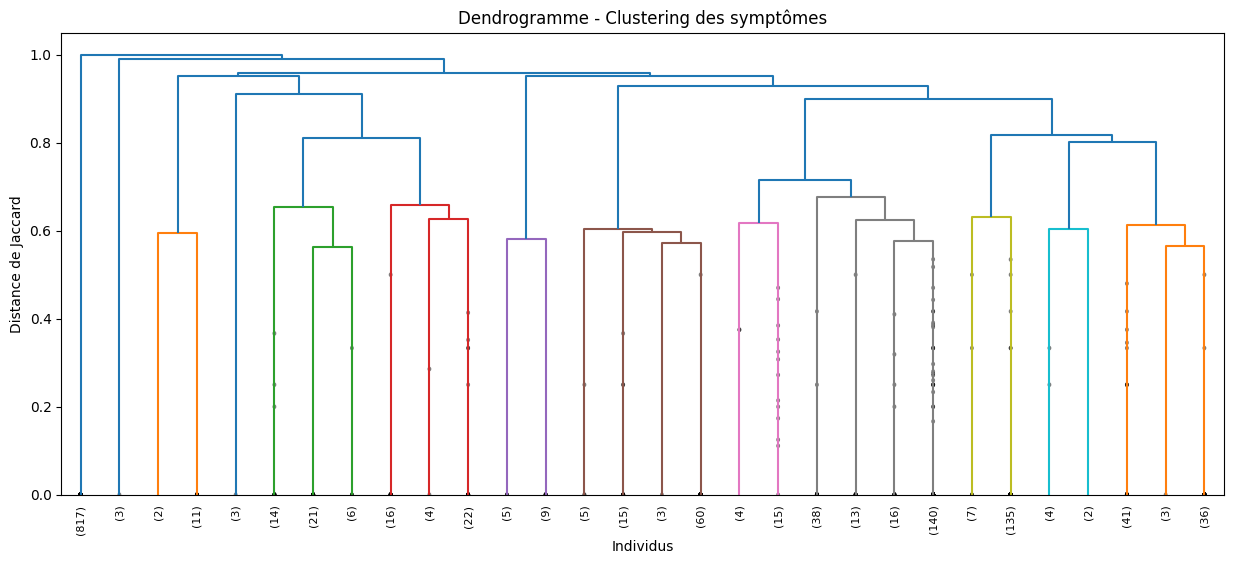

In [10]:
# Calcul de la matrice de distances de Jaccard entre les individus
dist_symptom = pdist(X_symptom, metric='jaccard')

# Linkage (méthode de Ward ou average ; on utilise 'average' car compatible avec Jaccard)
Z_symptom = linkage(dist_symptom, method='average')

# Tracer le dendrogramme
plt.figure(figsize=(15, 6))
dendrogram(Z_symptom, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8., show_contracted=True)
plt.title('Dendrogramme - Clustering des symptômes')
plt.xlabel('Individus')
plt.ylabel('Distance de Jaccard')
plt.show()

## 9. Détermination du nombre optimal de clusters (symptômes)
On teste k de 2 à 5 et on calcule le score de silhouette pour chaque partition issue du clustering hiérarchique (en coupant l'arbre).

In [11]:
silhouette_scores_symptom = []
K_range = range(2, 6)

for k in K_range:
    labels = fcluster(Z_symptom, k, criterion='maxclust')
    score = silhouette_score(X_symptom, labels, metric='jaccard')
    silhouette_scores_symptom.append(score)
    print(f"k={k}, silhouette score = {score:.4f}")

# Tracer les scores
fig = px.line(x=list(K_range), y=silhouette_scores_symptom, markers=True,
              title='Score de silhouette pour différents nombres de clusters (symptômes)',
              labels={'x': 'Nombre de clusters', 'y': 'Score de silhouette'})
fig.show()

k=2, silhouette score = 0.6358
k=3, silhouette score = 0.6339
k=4, silhouette score = 0.6429
k=5, silhouette score = 0.6408


### Choix du nombre de clusters
On sélectionne le k qui maximise le score de silhouette (ou un coude évident). Ici, on choisit k=... (à adapter selon le résultat).
Par exemple, si k=3 donne le meilleur score, on prend 3.

In [12]:
optimal_k_symptom = 3  # à ajuster d'après le graphique
labels_symptom = fcluster(Z_symptom, optimal_k_symptom, criterion='maxclust')
df_positif['Cluster_symptome'] = labels_symptom
print(f"Cluster attribués (symptômes) : {np.unique(labels_symptom, return_counts=True)}")

Cluster attribués (symptômes) : (array([1, 2, 3], dtype=int32), array([817,   3, 650], dtype=int64))


## 10. Description des clusters de symptômes

In [13]:
# Taille et pourcentage de chaque cluster
cluster_counts = df_positif['Cluster_symptome'].value_counts().sort_index()
cluster_percent = cluster_counts / len(df_positif) * 100
cluster_summary = pd.DataFrame({'Effectif': cluster_counts, 'Pourcentage': cluster_percent})
print("Résumé des clusters de symptômes :")
display(cluster_summary)

# Prévalence de chaque symptôme par cluster
prevalence_by_cluster = df_positif.groupby('Cluster_symptome')[symptom_cols_clean].mean().T
print("\nPrévalence des symptômes par cluster (en proportion) :")
display(prevalence_by_cluster)

Résumé des clusters de symptômes :


,Effectif,Pourcentage
Cluster_symptome,,
1,817,55.578231
2,3,0.204082
3,650,44.217687



Prévalence des symptômes par cluster (en proportion) :


Cluster_symptome,1,2,3
Céphalée,0.0,0.0,0.423077
Douleurs articulaires,0.0,0.0,0.329231
Fièvre,0.0,0.0,0.227692
Douleurs musculaires,0.0,0.0,0.304615
Douleurs abdominales,0.0,0.0,0.212308
Toux,0.0,0.0,0.115385
Rhinorrhée,0.0,0.0,0.130769
Nausées,0.0,0.0,0.052308
Vomissements,0.0,1.0,0.043077
Sueurs,0.0,0.0,0.047692


### Visualisation : heatmap des prévalences

In [14]:
# Heatmap avec Plotly
fig = px.imshow(prevalence_by_cluster.T,  # transposer pour avoir clusters en lignes, symptômes en colonnes
                text_auto='.2f',
                color_continuous_scale='Reds',
                title='Prévalence des symptômes par cluster',
                labels=dict(x='Symptôme', y='Cluster', color='Prévalence'))
fig.update_xaxes(tickangle=45)
fig.show()

### Bar chart de la distribution des clusters

In [15]:
fig = px.bar(x=cluster_counts.index, y=cluster_counts.values,
             text=cluster_counts.values,
             title='Distribution des clusters de symptômes',
             labels={'x': 'Cluster', 'y': 'Nombre d\'individus'},
             color=cluster_counts.index, color_continuous_scale='Viridis')
fig.show()

## 11. Interprétation des clusters de symptômes
On examine les symptômes les plus fréquents dans chaque cluster pour leur donner un nom.

In [16]:
# Pour chaque cluster, afficher les symptômes avec prévalence > 50% (ou un seuil)
for cluster in sorted(df_positif['Cluster_symptome'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    mask = df_positif['Cluster_symptome'] == cluster
    prev = df_positif.loc[mask, symptom_cols_clean].mean().sort_values(ascending=False)
    top_symptoms = prev[prev > 0.3].index.tolist()  # seuil à 30%
    print(f"Symptômes caractéristiques (prévalence > 30%) : {top_symptoms}")
    print(prev.round(2))


--- Cluster 1 ---
Symptômes caractéristiques (prévalence > 30%) : []
Céphalée                 0.0
Douleurs articulaires    0.0
Fièvre                   0.0
Douleurs musculaires     0.0
Douleurs abdominales     0.0
Toux                     0.0
Rhinorrhée               0.0
Nausées                  0.0
Vomissements             0.0
Sueurs                   0.0
Eruption cutanée         0.0
Odynophagie              0.0
Conjonctivite            0.0
dtype: float64

--- Cluster 2 ---
Symptômes caractéristiques (prévalence > 30%) : ['Vomissements']
Vomissements             1.0
Céphalée                 0.0
Douleurs articulaires    0.0
Fièvre                   0.0
Douleurs musculaires     0.0
Douleurs abdominales     0.0
Toux                     0.0
Rhinorrhée               0.0
Nausées                  0.0
Sueurs                   0.0
Eruption cutanée         0.0
Odynophagie              0.0
Conjonctivite            0.0
dtype: float64

--- Cluster 3 ---
Symptômes caractéristiques (prévalence > 30

### Exemples d'interprétation :
- Cluster 1 : peu de symptômes (profil asymptomatique ou pauci-symptomatique)
- Cluster 2 : symptômes respiratoires (toux, fièvre, dyspnée...)
- Cluster 3 : symptômes multiples (taux élevé de nombreux symptômes)

(À adapter selon les données réelles)

## 12. Association avec les variables démographiques

In [17]:
# Sexe
sex_cross = pd.crosstab(df_positif['Cluster_symptome'], df_positif['Sexe'], normalize='index') * 100
print("Répartition du sexe par cluster (en %) :")
display(sex_cross)

fig = px.bar(sex_cross, barmode='group', title='Sexe par cluster',
             labels={'value': 'Pourcentage', 'Cluster_symptome': 'Cluster'})
fig.show()

Répartition du sexe par cluster (en %) :


Sexe,Femme,Homme
Cluster_symptome,,
1,57.649939,42.350061
2,66.666667,33.333333
3,66.923077,33.076923


In [18]:
# Catégorie d'âge
age_cross = pd.crosstab(df_positif['Cluster_symptome'], df_positif['Categorie_age'], normalize='index') * 100
print("Répartition de la catégorie d'âge par cluster (en %) :")
display(age_cross)

fig = px.bar(age_cross, barmode='group', title='Catégorie d\'âge par cluster',
             labels={'value': 'Pourcentage', 'Cluster_symptome': 'Cluster'})
fig.show()

Répartition de la catégorie d'âge par cluster (en %) :


Categorie_age,Adolescent,Adulte,Enfant,Personne âgée
Cluster_symptome,,,,
1,28.029376,37.086903,21.664627,13.219094
2,0.000000,33.333333,66.666667,0.000000
3,22.923077,43.538462,14.923077,18.615385


In [19]:
# Quartier (top 10 quartiers par effectif global)
top_quartiers = df_positif['Quartier_corrige'].value_counts().head(10).index
df_top = df_positif[df_positif['Quartier_corrige'].isin(top_quartiers)]
quartier_cross = pd.crosstab(df_top['Cluster_symptome'], df_top['Quartier_corrige'], normalize='index') * 100

fig = px.bar(quartier_cross, barmode='group', title='Quartier par cluster (top 10 quartiers)',
             labels={'value': 'Pourcentage', 'Cluster_symptome': 'Cluster'})
fig.show()

## 13. Clustering des comorbidités
On répète les étapes pour les trois variables de comorbidités.

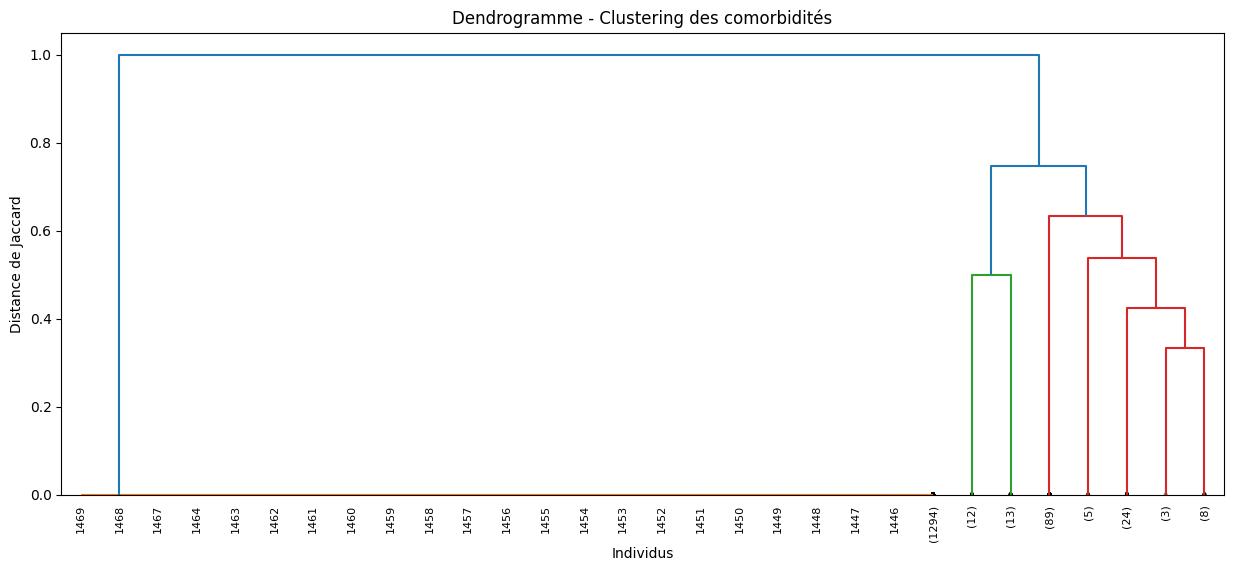

In [20]:
# Calcul de la matrice de distance de Jaccard pour les comorbidités
dist_comorb = pdist(X_comorbidity, metric='jaccard')
Z_comorb = linkage(dist_comorb, method='average')

# Dendrogramme
plt.figure(figsize=(15, 6))
dendrogram(Z_comorb, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8., show_contracted=True)
plt.title('Dendrogramme - Clustering des comorbidités')
plt.xlabel('Individus')
plt.ylabel('Distance de Jaccard')
plt.show()

In [21]:
# Score de silhouette pour comorbidités (k de 2 à 4 max car peu de variables)
silhouette_scores_comorb = []
K_range = range(2, 5)
for k in K_range:
    labels = fcluster(Z_comorb, k, criterion='maxclust')
    score = silhouette_score(X_comorbidity, labels, metric='jaccard')
    silhouette_scores_comorb.append(score)
    print(f"k={k}, silhouette score = {score:.4f}")

fig = px.line(x=list(K_range), y=silhouette_scores_comorb, markers=True,
              title='Score de silhouette - comorbidités',
              labels={'x': 'Nombre de clusters', 'y': 'Score'})
fig.show()

k=2, silhouette score = 0.9559
k=3, silhouette score = 0.9578
k=4, silhouette score = 0.9801


In [22]:
# Choix du nombre optimal (souvent 2 ou 3 pour trois variables)
optimal_k_comorb = 2  # à ajuster
labels_comorb = fcluster(Z_comorb, optimal_k_comorb, criterion='maxclust')
df_positif['Cluster_comorbidite'] = labels_comorb
print(f"Clusters de comorbidités : {np.unique(labels_comorb, return_counts=True)}")

Clusters de comorbidités : (array([1, 2], dtype=int32), array([1316,  154], dtype=int64))


In [23]:
# Description des clusters de comorbidités
comorb_counts = df_positif['Cluster_comorbidite'].value_counts().sort_index()
comorb_percent = comorb_counts / len(df_positif) * 100
print("Résumé clusters comorbidités :")
display(pd.DataFrame({'Effectif': comorb_counts, 'Pourcentage': comorb_percent}))

prevalence_comorb = df_positif.groupby('Cluster_comorbidite')[comorbidity_cols].mean().T
print("Prévalence des comorbidités par cluster :")
display(prevalence_comorb)

# Heatmap
fig = px.imshow(prevalence_comorb.T, text_auto='.2f', color_continuous_scale='Blues',
                title='Prévalence des comorbidités par cluster',
                labels=dict(x='Comorbidité', y='Cluster'))
fig.show()

Résumé clusters comorbidités :


,Effectif,Pourcentage
Cluster_comorbidite,,
1,1316,89.52381
2,154,10.47619


Prévalence des comorbidités par cluster :


Cluster_comorbidite,1,2
Diabte,0.0,0.233766
HTA,0.0,0.870130
Maladie_cardiaque,0.0,0.259740


## 14. Interprétation des clusters de comorbidités
On peut identifier :
- Cluster 1 : peu ou pas de comorbidités
- Cluster 2 : présence de diabète, HTA, etc.

## 15. Conclusion
### Profils identifiés :
- ...
### Patterns symptomatiques distincts :
- ...
### Groupes à risque plus élevé :
- Les clusters avec comorbidités multiples ou symptômes sévères pourraient représenter des groupes à risque.

À compléter après analyse des résultats réels.

## 16. Sauvegarde des résultats (optionnel)
On peut exporter le dataframe avec les clusters.

In [24]:
# df_positif.to_csv('resultats_clusters.csv', index=False)
print("Analyse terminée.")

Analyse terminée.
